<a href="https://colab.research.google.com/github/abrown12005/BME-4972_4973/blob/main/ImagesInMedicine/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm
from scipy.stats import ttest_ind

RunningInCOLAB = 'google.colab' in str(get_ipython())
if RunningInCOLAB:
    # clone github repo with the data
    !git clone https://github.com/abrown12005/BME-4972_4973.git
    %cd BME-4972_4973/ImagesInMedicine

#Load and read the data
file_path = 'HW4.csv'
data = pd.read_csv(file_path,header=None)

healthy = data[0].to_numpy()
Schmooples = data[1].to_numpy()

Cloning into 'BME-4972_4973'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 61 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (61/61), 272.26 KiB | 6.48 MiB/s, done.
Resolving deltas: 100% (13/13), done.
/content/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine/BME-4972_4973/ImagesInMedicine


P-Value:1.4108101454349842e-14
T-Statistic:-8.32


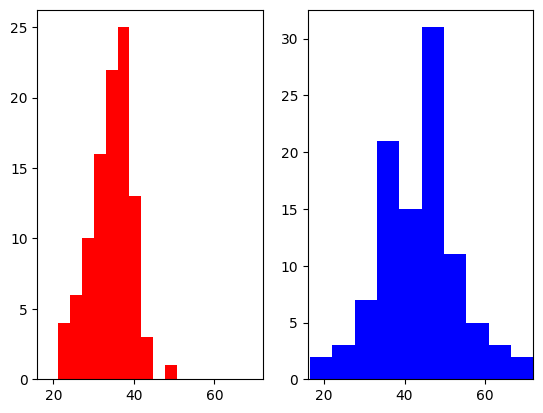

In [64]:
#Problem 1
#What is the probability that these two results came from the same dataset?
t_test = ttest_ind(healthy,Schmooples)

#Get the max and min to have the same x limits
x_max = np.maximum(np.max(healthy),np.max(Schmooples))
x_min = np.minimum(np.min(healthy),np.min(Schmooples))

fig, (ax1,ax2) = plt.subplots(1,2)
ax1.hist(healthy,color='r',bins=10)
ax1.set_xlim(int(x_min),int(x_max))

ax2.hist(Schmooples,color='b',bins=10)
ax2.set_xlim(int(x_min),int(x_max))

print(f'P-Value:{t_test.pvalue}')
print(f'T-Statistic:{t_test.statistic:.4}')

With a pvalue that low and a t-statistic that high(or very negative), it is very unlikely that these two sets of results emerged from the same dataset.

Text(0.5, 1.0, 'QQ Plot')

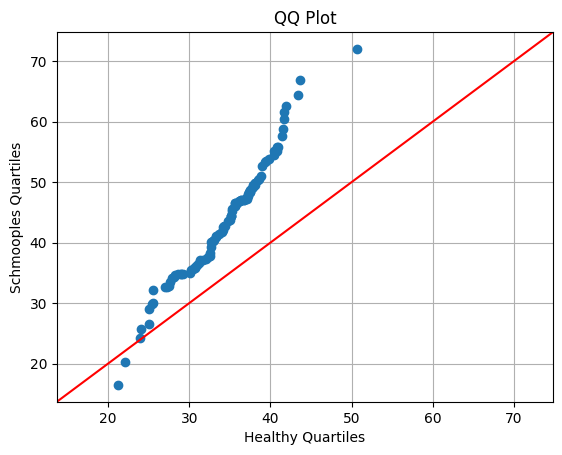

In [65]:
#Problem 2
#Create a QQ plot of this data
pp_x = sm.ProbPlot(healthy)
pp_y = sm.ProbPlot(Schmooples)
fig = sm.qqplot_2samples(pp_x, pp_y, line='45')
plt.grid('on')
plt.xlabel('Healthy Quartiles')
plt.ylabel('Schmooples Quartiles')
plt.title('QQ Plot')

Text(0.5, 1.0, 'ROC')

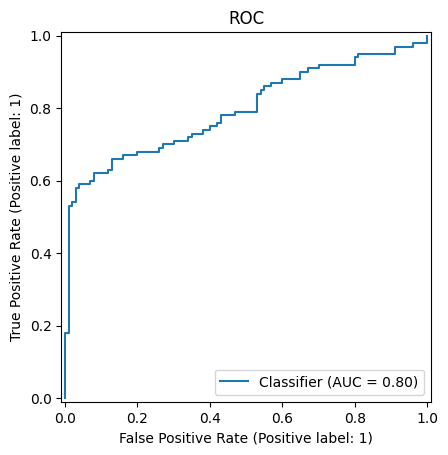

In [66]:
#Problem 3
#Make an ROC curve of this data
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, roc_curve

#Create a binary array for healthy and disease
y = np.concatenate((np.zeros(len(healthy)), np.ones(len(Schmooples))))

#Combine healthy and disease numbers together
x = np.concatenate((healthy, Schmooples))

fpr, tpr, thr = roc_curve(y, x)

RocCurveDisplay.from_predictions(y, x)
plt.title("ROC")

In [71]:
#Problem 4
#Identify the best threshold at which healthy/schmooples cases are best separated
best = thr[np.argmax(tpr - fpr)]
print(f"J statistic: {best:.2f}")

J statistic: 42.04


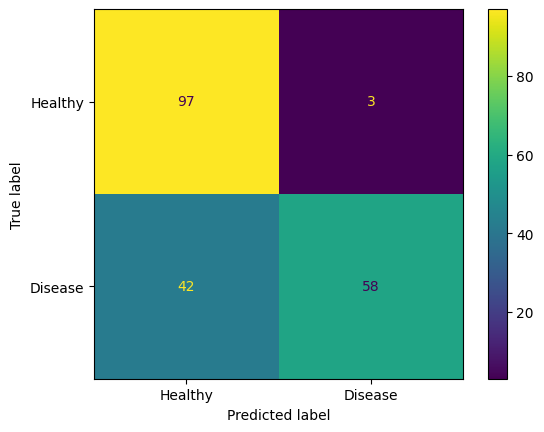

In [68]:
#Problem 5
#Make a confusion matrix for the data given your choice of threshold
ConfusionMatrixDisplay.from_predictions(y, x >= best, display_labels=['Healthy', 'Disease'])

In [70]:
#Problem 6
#What is the sensitivity and specificity of the 'plook' index given your threshold?
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y, x >= best).flatten()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"Sensitivity: {sensitivity:.3f}, Specificity: {specificity:.3f}")

Sensitivity: 0.580, Specificity: 0.970


Problems 1, 2, and 4 were created by hand. Problems 3, 5, and 6 were helped with Claude.